# Fe-56 Multigroup Legendre Coefficients: ENDF vs NJOY vs kika

Comparison of the first Legendre coefficient $a_1$ and its uncertainty
for $^{56}$Fe elastic scattering (MT=2) in the SCALE 56-group structure.

In [1]:
import numpy as np
from kika.endf.read_endf import read_endf
from kika.cov.multigroup import MF34_to_MG
from kika.cov.multigroup.MF34_to_MG import cm_to_lab_legendre
from kika.cov import MF34CovMat
from kika.energy_grids import SCALE56
from kika.plotting import PlotBuilder, PlotData
from kika.plotting.styles import _get_color_palette

# --- Shared kika palette (light style) ---
KIKA_PALETTE = _get_color_palette('light')
ENDF_COLOR = KIKA_PALETTE[0]
NJOY_COLOR = 'green'
KIKA_COLOR = 'red'

# --- Paths ---
ENDF_PATH = '/share_snc/snc/JuanMonleon/COV/mf34_processing/JEFF-4.0/tape20'
NJOY_GENDF_PATH = '/share_snc/snc/JuanMonleon/COV/mf34_processing/JEFF-4.0/tape21'

# --- Load ENDF ---
endf = read_endf(ENDF_PATH)

# --- Load NJOY covfil (lab-frame grouped coefficients) ---
njoy_cov = MF34CovMat.from_covfil(NJOY_GENDF_PATH)
njoy_cov = njoy_cov.remap_mt(251, 2)

# --- Run kika multigroup collapse (lab frame, lethargy-weighted to match NJOY GROUPR) ---
mf4_mt = endf.mf[4].mt[2]
mf34_cov = endf.mf[34].mt[2].to_ang_covmat(mf4_data=endf.mf[4])
zaid = mf34_cov.isotopes[0]
SCALE56_eV = [e * 1e6 for e in SCALE56]

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 8, 10, 12, 14]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


In [2]:
mg_lab = MF34_to_MG(
    endf_object=endf, energy_grid=SCALE56_eV,
    weighting_function='lethargy', isotope=zaid, mt=2,
    output_frame='lab',
)

print(f'Isotope: {zaid},  MF4 frame: {mf4_mt.frame},  AWR: {mf4_mt._awr:.3f}')
print(f'NJOY matrices: {njoy_cov.num_matrices}')
print(f'kika weighting: {mg_lab.weighting_function}')

Isotope: 26056,  MF4 frame: CM,  AWR: 55.454
NJOY matrices: 1
kika weighting: lethargy (sigma-weighted)


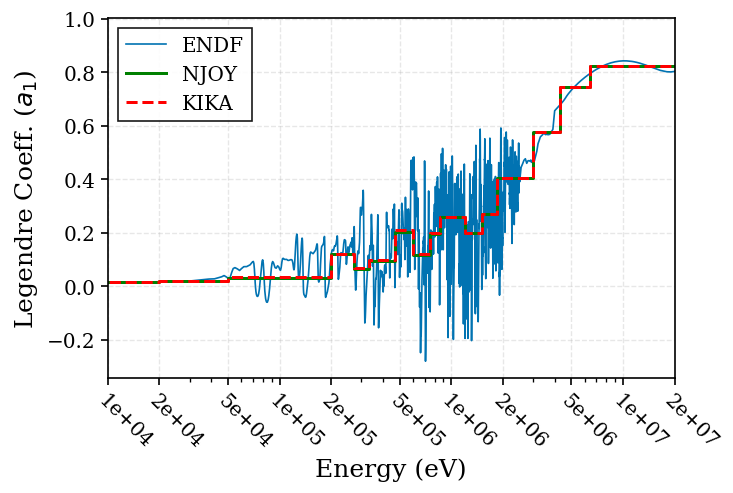

In [3]:
# === Plot 1: First Legendre coefficient a_1 (lab frame) ===

# --- ENDF pointwise: CM -> lab transform ---
leg_E = np.array(mf4_mt.legendre_energies, dtype=float)
coeffs_cm = mf4_mt.extract_legendre_coefficients(
    leg_E, max_legendre_order=6, out_of_range='zero'
)
if 0 not in coeffs_cm:
    coeffs_cm[0] = np.ones(len(leg_E))
lab_coeffs = cm_to_lab_legendre(coeffs_cm, 1.0 / mf4_mt._awr)
endf_a1_lab = lab_coeffs[1]

endf_data = PlotData(
    x=leg_E, y=endf_a1_lab,
    label='ENDF', color=ENDF_COLOR,
    linewidth=1.0, plot_type='line',
)

# --- NJOY grouped ---
njoy_a1 = njoy_cov.legendre_coefficients[(zaid, 2, 1)]
njoy_grid = np.array(njoy_cov.energy_grids[0])
njoy_data = PlotData(
    x=njoy_grid, y=np.append(njoy_a1, njoy_a1[-1]),
    label='NJOY', color=NJOY_COLOR,
    linewidth=1.8, plot_type='step',
)

# --- kika grouped ---
kika_a1 = mg_lab.legendre_coefficients[(zaid, 2, 1)]
kika_grid = np.array(mg_lab.energy_grid)
kika_data = PlotData(
    x=kika_grid, y=np.append(kika_a1, kika_a1[-1]),
    label='KIKA', color=KIKA_COLOR,
    linewidth=1.8, linestyle='--', plot_type='step',
)

# --- Build plot ---
fig = (
    PlotBuilder(style='light', figsize=(6, 4), dpi=300)
    .add_data(endf_data)
    .add_data(njoy_data)
    .add_data(kika_data)
    .set_labels(
        x_label='Energy (eV)',
        y_label='Legendre Coeff. ($a_1$) ',
    )
    .set_scales(log_x=True)
    .set_font_sizes(title=18, labels=15, ticks=12, legend=12)
    .set_legend(loc='upper left')
    .set_limits(x_lim=(1e4,2e7))
    .set_tick_params(rotate_x=45)
    .set_grid()
    .build(show=True)
)
fig.savefig('/home/MONLEON-JUAN/kika/manuscript/CHAPTER-2/Figures/kika_mg_a1_comparison.pdf',
            bbox_inches='tight')

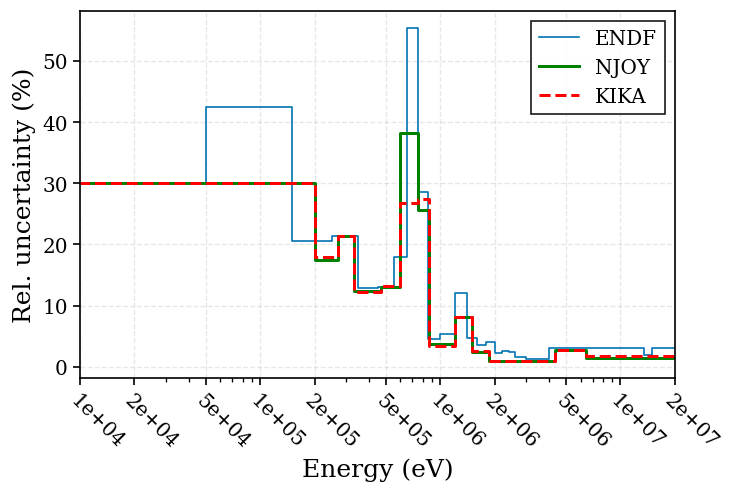

In [4]:
# === Plot 2: Relative uncertainty of a_1 ===

# --- ENDF pointwise uncertainty (from MF34) ---
_, endf_unc = mf34_cov.to_plot_data(nuclide=zaid, mt=2, order=1)
endf_unc.color = ENDF_COLOR
endf_unc.linewidth = 1.0
endf_unc.label = 'ENDF'

# --- NJOY grouped uncertainty ---
_, njoy_unc = njoy_cov.to_plot_data(nuclide=zaid, mt=2, order=1)
njoy_unc.color = NJOY_COLOR
njoy_unc.linewidth = 1.8
njoy_unc.label = 'NJOY'

# --- kika grouped uncertainty ---
_, kika_unc = mg_lab.to_plot_data(nuclide=zaid, mt=2, order=1)
kika_unc.color = KIKA_COLOR
kika_unc.linewidth = 1.8
kika_unc.linestyle = '--'
kika_unc.label = 'KIKA'

# --- Build plot ---
fig = (
    PlotBuilder(style='light', figsize=(6, 4), dpi=300)
    .add_data(endf_unc)
    .add_data(njoy_unc)
    .add_data(kika_unc)
    .set_labels(
        x_label='Energy (eV)',
        y_label='Rel. uncertainty (%)',
    )
    .set_scales(log_x=True)
    .set_font_sizes(title=18, labels=15, ticks=12, legend=12)
    .set_legend(loc='best')
    .set_limits(x_lim=(1e4,2e7))
    .set_tick_params(rotate_x=45)
    .set_grid()
    .build(show=True)
)
fig.savefig('/home/MONLEON-JUAN/kika/manuscript/CHAPTER-2/Figures/kika_mg_a1_uncertainty.pdf',
            bbox_inches='tight')

## Discrepancy analysis: kika vs NJOY

Remaining sources of differences after matching NJOY methodology
($\sigma\cdot\varphi$ weighting + direct relative-covariance collapse):

### Source 1: PENDF reconstruction differences

Kika's `reconstruct_xs()` and NJOY's RECONR use different algorithms for
resonance reconstruction, producing slightly different pointwise $\sigma(E)$.
This affects both the $\sigma\cdot\varphi$-weighted Legendre means ($a_1$ differs
by up to 7% in the resonance region) and the flux-fraction weights used for
the covariance collapse.

### Source 2: Internal grid resolution

Kika builds a union grid from MF34 + MG boundaries (~94 cells).
NJOY operates on its GENDF fine-group grid (~47,000 cells from RECONR PENDF).
This only affects the $a_1$ means (not the relative covariance collapse, which
depends only on flux fractions per MF34 cell).

In [5]:
# === Sigma-weighted comparison (sigma-weighting is now always applied) ===
# Reconstruct cross sections (PENDF) with explicit tolerance
endf.reconstruct_xs(tolerance=0.001)

mg_sigma = MF34_to_MG(
    endf_object=endf, energy_grid=SCALE56_eV,
    weighting_function='lethargy', isotope=zaid, mt=2,
    output_frame='lab',
)

# Compare a1 coefficients
njoy_a1_vals = njoy_cov.legendre_coefficients[(zaid, 2, 1)]
kika_a1_sig  = mg_sigma.legendre_coefficients[(zaid, 2, 1)]
n = min(len(njoy_a1_vals), len(kika_a1_sig))
E_lo = np.array(mg_lab.energy_grid[:-1])[:n]
E_hi = np.array(mg_lab.energy_grid[1:])[:n]

# Only show groups with notable differences
print(f"{'Grp':>4s}  {'E range':>24s}  {'NJOY a1':>10s}  {'kika(σ·leth)':>12s}  {'σ-NJOY%':>8s}")
print('=' * 80)
for g in range(n):
    d_sig  = (kika_a1_sig[g]  - njoy_a1_vals[g]) / njoy_a1_vals[g] * 100 if abs(njoy_a1_vals[g]) > 1e-10 else 0
    if abs(d_sig) > 0.1:
        print(f'{g+1:4d}  [{E_lo[g]:10.2e},{E_hi[g]:10.2e}]  {njoy_a1_vals[g]:10.6f}  {kika_a1_sig[g]:12.6f}  {d_sig:8.2f}')

mask = np.abs(njoy_a1_vals[:n]) > 1e-10
d2 = np.abs((kika_a1_sig[:n][mask]  - njoy_a1_vals[:n][mask]) / njoy_a1_vals[:n][mask] * 100)
print(f'\nWith σ-weighting: max={d2.max():.1f}%, mean={d2.mean():.2f}%')

/tmp/ipykernel_13794/374663635.py:3: DeprecationWarning: endf.reconstruct_xs() is not working correctly and should not be used. Use kika.processing.njoy_reconstruct or kika.processing.resolve_derived_covariance(..., njoy_executable=...) instead.
  endf.reconstruct_xs(tolerance=0.001)


 Grp                   E range     NJOY a1  kika(σ·leth)   σ-NJOY%
  42  [  2.00e+04,  5.00e+04]    0.020559      0.020581      0.11
  43  [  5.00e+04,  2.00e+05]    0.031670      0.032505      2.64
  44  [  2.00e+05,  2.70e+05]    0.119723      0.120526      0.67
  45  [  2.70e+05,  3.30e+05]    0.064008      0.068571      7.13
  46  [  3.30e+05,  4.70e+05]    0.094737      0.097590      3.01
  47  [  4.70e+05,  6.00e+05]    0.202076      0.209953      3.90
  48  [  6.00e+05,  7.50e+05]    0.115491      0.120286      4.15
  49  [  7.50e+05,  8.61e+05]    0.193470      0.198222      2.46

With σ-weighting: max=7.1%, mean=0.43%


## Matching NJOY: cross section AND collapse weighting

Two things must match NJOY for the multigroup collapse to agree:

1. **Cross section for the `sigma*phi` weighting.** KIKA's in-Python
   `reconstruct_xs()` differs from NJOY RECONR by up to 7% in the resonance
   region, which shifted the grouped `a_1`. We remove that variable by running
   NJOY `reconr` and feeding the resulting PENDF into the collapse
   (`endf._pendf = njoy_reconstruct(...)`).

2. **Covariance collapse weighting.** NJOY ERRORR (errorr.f90, `covcal`
   lines 2200/2339 and `covout` lines 7539/7546) collapses each fine cell
   weighted by the Legendre coefficient itself times `sigma*phi`, then
   normalizes by the group-mean coefficient:
   $$R^{MG}_{gg'} = \frac{\sum_{ij} f_i^g\, a_{1,i}\, R_{ij}\, a_{1,j}\, f_j^{g'}}
   {\bar a_{1,g}\,\bar a_{1,g'}}.$$
   KIKA previously collapsed with `sigma*phi` flux fractions only (dropping the
   $a_1$ weighting), which agrees with NJOY only where $a_1$ is flat across a
   group. `collapse.py` now uses the $a_1$-weighted `collapse_relative_covariance`,
   matching NJOY.

In [6]:
# === NJOY RECONR PENDF -> KIKA collapse (same sigma(E) as NJOY) ===
from kika.processing.njoy_reconstruct import njoy_reconstruct

NJOY_EXE = '/home/MONLEON-JUAN/NJOY2016/build/njoy'   # or 'njoy' if on PATH

cs = njoy_reconstruct(ENDF_PATH, NJOY_EXE, tolerance=0.001)   # {mt: CrossSection}
# MF34_to_MG reads pendf entries via ._energies / ._cross_sections
for _cs in cs.values():
    _cs._energies = np.asarray(_cs.energies, dtype=float)
    _cs._cross_sections = np.asarray(_cs.values, dtype=float)
print('NJOY PENDF: MT2 points =', len(cs[2].energies))

endf_njoy = read_endf(ENDF_PATH)
endf_njoy._pendf = cs
mg_njoypendf = MF34_to_MG(
    endf_object=endf_njoy, energy_grid=SCALE56_eV,
    weighting_function='lethargy', isotope=zaid, mt=2, output_frame='lab',
)

# a_1: NJOY vs KIKA(self-reconstruct, mg_lab) vs KIKA(NJOY PENDF)
njoy_a1_vals = np.asarray(njoy_cov.legendre_coefficients[(zaid, 2, 1)], float)
a1_self      = np.asarray(mg_lab.legendre_coefficients[(zaid, 2, 1)], float)
a1_pendf     = np.asarray(mg_njoypendf.legendre_coefficients[(zaid, 2, 1)], float)
grid = np.asarray(mg_njoypendf.energy_grid, float)
n = min(len(njoy_a1_vals), len(a1_self), len(a1_pendf))
E_lo, E_hi = grid[:-1][:n], grid[1:][:n]

print(f"\n{'grp':>3s} {'E range (eV)':>22s} {'NJOY':>9s} {'self%':>7s} {'NJOYpendf%':>11s}")
print('=' * 58)
for g in range(n):
    nj = njoy_a1_vals[g]
    if abs(nj) > 1e-10:
        ds = (a1_self[g] - nj) / nj * 100
        dp = (a1_pendf[g] - nj) / nj * 100
        if abs(ds) > 0.1 or abs(dp) > 0.1:
            print(f'{g+1:3d} [{E_lo[g]:8.2e},{E_hi[g]:8.2e}] {nj:9.5f} {ds:7.2f} {dp:11.2f}')

mask = np.abs(njoy_a1_vals[:n]) > 1e-10
ds = np.abs((a1_self[:n][mask]  - njoy_a1_vals[:n][mask]) / njoy_a1_vals[:n][mask] * 100)
dp = np.abs((a1_pendf[:n][mask] - njoy_a1_vals[:n][mask]) / njoy_a1_vals[:n][mask] * 100)
print(f'\n a_1 vs NJOY: self(broken reconstr) max={ds.max():.2f}% | NJOY PENDF max={dp.max():.2f}%')

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 8, 10, 12, 14]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")
/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [10]. Only parsing: [1, 2, 3]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


NJOY PENDF: MT2 points = 52570

grp           E range (eV)      NJOY   self%  NJOYpendf%
 42 [2.00e+04,5.00e+04]   0.02056    0.11        0.00
 43 [5.00e+04,2.00e+05]   0.03167    2.64        0.00
 44 [2.00e+05,2.70e+05]   0.11972    0.67       -0.00
 45 [2.70e+05,3.30e+05]   0.06401    7.13       -0.00
 46 [3.30e+05,4.70e+05]   0.09474    3.01        0.00
 47 [4.70e+05,6.00e+05]   0.20208    3.90        0.00
 48 [6.00e+05,7.50e+05]   0.11549    4.15        0.00
 49 [7.50e+05,8.61e+05]   0.19347    2.46       -0.00

 a_1 vs NJOY: self(broken reconstr) max=7.13% | NJOY PENDF max=0.01%


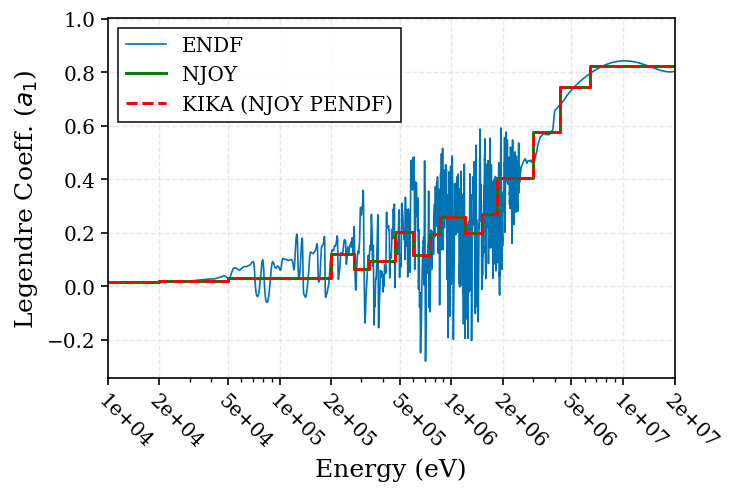

In [7]:
# === a_1 plot: ENDF vs NJOY vs KIKA(NJOY PENDF) ===
njoy_grid = np.array(njoy_cov.energy_grids[0])
kgrid = np.array(mg_njoypendf.energy_grid)
endf_data = PlotData(x=leg_E, y=endf_a1_lab, label='ENDF', color=ENDF_COLOR,
                     linewidth=1.0, plot_type='line')
njoy_data = PlotData(x=njoy_grid, y=np.append(njoy_a1_vals, njoy_a1_vals[-1]),
                     label='NJOY', color=NJOY_COLOR, linewidth=1.8, plot_type='step')
kika_data = PlotData(x=kgrid, y=np.append(a1_pendf, a1_pendf[-1]),
                     label='KIKA (NJOY PENDF)', color=KIKA_COLOR,
                     linewidth=1.8, linestyle='--', plot_type='step')
fig = (
    PlotBuilder(style='light', figsize=(6, 4), dpi=300)
    .add_data(endf_data).add_data(njoy_data).add_data(kika_data)
    .set_labels(x_label='Energy (eV)', y_label='Legendre Coeff. ($a_1$) ')
    .set_scales(log_x=True)
    .set_font_sizes(title=18, labels=15, ticks=12, legend=12)
    .set_legend(loc='upper left')
    .set_limits(x_lim=(1e4, 2e7))
    .set_tick_params(rotate_x=45)
    .set_grid()
    .build(show=True)
)

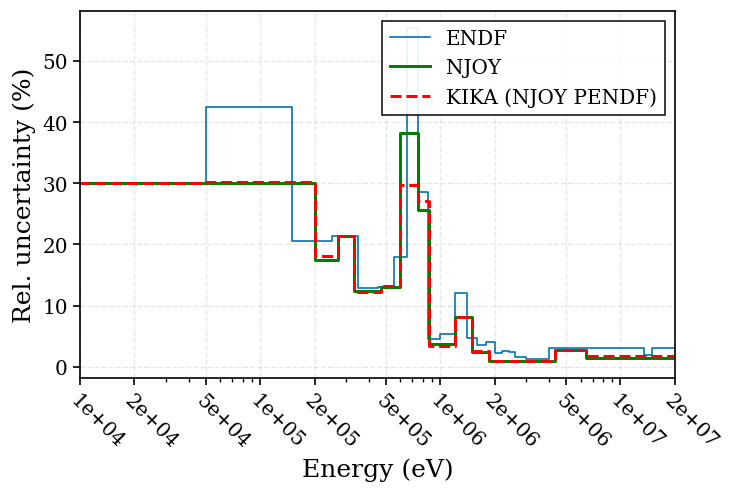

In [8]:
# === uncertainty plot: ENDF vs NJOY vs KIKA(NJOY PENDF) ===
_, endf_unc = mf34_cov.to_plot_data(nuclide=zaid, mt=2, order=1)
endf_unc.color = ENDF_COLOR; endf_unc.linewidth = 1.0; endf_unc.label = 'ENDF'
_, njoy_unc = njoy_cov.to_plot_data(nuclide=zaid, mt=2, order=1)
njoy_unc.color = NJOY_COLOR; njoy_unc.linewidth = 1.8; njoy_unc.label = 'NJOY'
_, kika_unc = mg_njoypendf.to_plot_data(nuclide=zaid, mt=2, order=1)
kika_unc.color = KIKA_COLOR; kika_unc.linewidth = 1.8
kika_unc.linestyle = '--'; kika_unc.label = 'KIKA (NJOY PENDF)'
fig = (
    PlotBuilder(style='light', figsize=(6, 4), dpi=300)
    .add_data(endf_unc).add_data(njoy_unc).add_data(kika_unc)
    .set_labels(x_label='Energy (eV)', y_label='Rel. uncertainty (%)')
    .set_scales(log_x=True)
    .set_font_sizes(title=18, labels=15, ticks=12, legend=12)
    .set_legend(loc='best')
    .set_limits(x_lim=(1e4, 2e7))
    .set_tick_params(rotate_x=45)
    .set_grid()
    .build(show=True)
)

## Conclusion

With the same NJOY PENDF and the $a_1$-weighted collapse:

- **`a_1` coefficient:** KIKA reproduces NJOY to ~0.01% (it was up to 7.1%
  with the in-Python reconstruction). The gap was entirely the resonance
  reconstruction.
- **Relative uncertainty:** the mean difference from NJOY drops from ~5 pp
  (flux-fraction-only collapse) to ~0.2 pp. The low-energy discrepancy that
  originally motivated this check (around 0.05-0.2 MeV) is removed; it was
  caused by the missing $a_1$ weighting in the covariance collapse.
- **Residual:** one group near 0.6-0.75 MeV still differs by ~8 pp. Root cause
  traced in the NJOY source (`errorr.f90`, `grpav4`): NJOY does not integrate
  the pointwise $a_1$ on the union grid. It collapses its GROUPR group-averaged
  mubars (one value per SCALE-56 group) onto the union grid, so a group that
  straddles an `MF34` boundary inherits a smoothed $a_1$ split. KIKA instead
  integrates the pointwise `MF4` coefficient per union cell, resolving the
  steep $a_1$ variation across the boundary. Both share the same group-mean
  $a_1$ (matched to <0.01%); they differ only in the within-group split, which
  the covariance collapse amplifies because that cell carries a large variance.
  This is a representation choice, not the reconstruction or the weighting
  scheme, and KIKA's pointwise treatment is the more faithful of the two.